In [1]:
from pathlib import Path
import sys
repo_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(repo_root / "src"))

%load_ext autoreload
%autoreload 2
import soccer_pattern_recognition as sc

import os
import time
import tqdm
import numpy as np
import pandas as pd

from sklearn.neighbors import LocalOutlierFactor
import matplotlib.pyplot as plt
import socceraction.spadl as spadl

In [2]:
datafolder = "../data"
fifa2018h5 = os.path.join(datafolder, "spadl-fifa2018.h5")
games = pd.read_hdf(fifa2018h5, key="games")
with pd.HDFStore(fifa2018h5) as store:
    actions = []  #list of DataFrames
    for game in tqdm.tqdm(games.itertuples()):
        game_action = store[f"actions/game_{game.game_id}"]
        game_action = spadl.play_left_to_right(game_action, game.home_team_id)
        game_action["is_home"] = game_action["team_id"] == game.home_team_id
        actions.append(game_action)
    actions = pd.concat(actions)
    actions.drop("original_event_id", axis=1, inplace=True)
    actions = pd.merge(actions, spadl.config.actiontypes_df(), how="left")

64it [00:00, 179.92it/s]


In [3]:
def consolidate(actions):
    #actions.fillna(0, inplace=True)

    #Consolidate corner_short and corner_crossed
    corner_idx = actions.type_name.str.contains("corner")
    actions["type_name"] = actions["type_name"].mask(corner_idx, "corner")

    #Consolidate freekick_short, freekick_crossed, and shot_freekick
    freekick_idx = actions.type_name.str.contains("freekick")
    actions["type_name"] = actions["type_name"].mask(freekick_idx, "freekick")

    #Consolidate keeper_claim, keeper_punch, keeper_save, keeper_pick_up
    keeper_idx = actions.type_name.str.contains("keeper")
    actions["type_name"] = actions["type_name"].mask(keeper_idx, "keeper_action")

    actions["start_x"] = actions["start_x"].mask(actions.type_name == "shot_penalty", 94.5)
    actions["start_y"] = actions["start_y"].mask(actions.type_name == "shot_penalty", 34)

    return actions

def add_noise(actions):
    # Start locations
    start_list = ["cross", "shot", "dribble", "pass", "keeper_action", "clearance", "goalkick"]
    mask = actions["type_name"].isin(start_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["start_x", "start_y"]].shape)
    actions.loc[mask, ["start_x", "start_y"]] += noise

    # End locations
    end_list = ["cross", "shot", "dribble", "pass", "keeper_action", "throw_in", "corner", "freekick", "shot_penalty"]
    mask = actions["type_name"].isin(end_list)
    noise = np.random.normal(0, 0.5, size=actions.loc[mask, ["end_x", "end_y"]].shape)
    actions.loc[mask, ["end_x", "end_y"]] += noise

    return actions

In [4]:
def _add_sequence_columns(df: pd.DataFrame) -> pd.DataFrame:
    """
    Given a dataframe with a boolean column `new_poss`,
    add:
        - poss_id
        - idx_in_seq
        - seq_length
    """
    df = df.copy()

    df["poss_id"] = df["new_poss"].cumsum()
    df["idx_in_seq"] = df.groupby("poss_id").cumcount()
    df["seq_length"] = df.groupby("poss_id")["poss_id"].transform("size")

    return df

def prepare_data(actions: pd.DataFrame, action_map: dict):
    """
    Prepare soccer action data for modeling.

    Steps
    -----
    1. Consolidate and perturb coordinates.
    2. Compute action angle and its cosine/sine.
    3. Map action names to integer ids.
    4. Detect possession boundaries.
    5. Build possession sequence features.
    6. Keep only modeled actions and sequences of length >= 3.
    7. Recompute sequence indexing after filtering.
    8. Return feature matrix X and sequence lengths.

    Returns
    -------
    X : np.ndarray
        Array with columns:
        [action_type_id, start_x, start_y, cos_angle, sin_angle]

    lengths : np.ndarray
        Length of each possession sequence, in possession-id order.
    """
    actions = actions.copy()

    # Basic preprocessing
    actions = consolidate(actions)
    actions = add_noise(actions)

    # Directional features
    dx = actions["end_x"] - actions["start_x"]
    dy = actions["end_y"] - actions["start_y"]
    actions["angle"] = np.arctan2(dy, dx)
    actions["cos_angle"] = np.cos(actions["angle"])
    actions["sin_angle"] = np.sin(actions["angle"])

    # Action id
    actions["action_type_id"] = actions["type_name"].map(action_map)

    # Possession starts
    actions["new_poss"] = (
        (actions.index == 0)
        | (actions["game_id"] != actions["game_id"].shift(1))
        | (actions["period_id"] != actions["period_id"].shift(1))
        | (actions["team_id"] != actions["team_id"].shift(1))
        | (actions["type_name"] == "goalkick")
        | (actions["type_name"] == "freekick")
        | (actions["type_name"].shift(1) == "shot")
        | (actions["type_name"].shift(1) == "bad_touch")
        | (actions["type_name"].shift(1) == "foul")
    )

    # Add initial sequence info
    actions = _add_sequence_columns(actions)

    # Keep only actions modeled in action_map and sequences with length >= 3
    valid_action = actions["type_name"].isin(action_map)
    long_enough_seq = actions["seq_length"] >= 3
    df = actions.loc[valid_action & long_enough_seq].copy()

    # IMPORTANT:
    # after filtering, rebuild new_poss so sequence boundaries are still valid
    # in the filtered dataframe
    df["new_poss"] = (
        (df.index == df.index[0])
        | (df["game_id"] != df["game_id"].shift(1))
        | (df["period_id"] != df["period_id"].shift(1))
        | (df["team_id"] != df["team_id"].shift(1))
        | (df["type_name"] == "goalkick")
        | (df["type_name"] == "freekick")
        | (df["type_name"].shift(1) == "shot")
        | (df["type_name"].shift(1) == "bad_touch")
        | (df["type_name"].shift(1) == "foul")
    )

    df = _add_sequence_columns(df)

    # Feature matrix
    X = df[[
        "action_type_id",
        "start_x",
        "start_y",
        "cos_angle",
        "sin_angle",
    ]].to_numpy()

    # One length per possession
    lengths = (
        df.groupby("poss_id")
        .size()
        .to_numpy()
    )

    return X, lengths

In [5]:
emission_hyperparams = {'clearance': [4, "k-means",2,"k-means"],
              'corner': [2, "k-means",2,"k-means"],
              'cross': [4, "k-means",2,"k-means"],
              'dribble': [5, "k-means",2,"k-means"],
              'freekick': [3, "k-means",2,"k-means"],
              'goalkick': [2, "k-means",2,"k-means"],
              'keeper_action': [3, "k-means",2,"k-means"],
              'pass': [5, "k-means",2,"k-means"],
              'shot': [3, "k-means",2,"k-means"],
              'throw_in': [6, "k-means",2,"k-means"]}

model = sc.TwoLayerHMM(emission_hyperparams,2)

In [7]:
ACTION_MAP = {'clearance': 0,
              'corner': 1,
              'cross': 2,
              'dribble': 3,
              'freekick': 4,
              'goalkick': 5,
              'keeper_action': 6,
              'pass': 7,
              'shot': 8,
              'throw_in': 9}

X, lenghts = prepare_data(actions, ACTION_MAP)

In [8]:
model.fit(X, lenghts)

/Users/jgv/PycharmProjects/soccer-pattern-recognition/src/soccer_pattern_recognition/hierarchical/two_layer.py:103: RuntimeWarning: divide by zero encountered in log
  return logsumexp(np.log(loc_pdf) + dir_log_pdf, axis=1)  # (N,)


,emission_hyperparams,"{'clearance': [4, 'k-means', ...], 'corner': [2, 'k-means', ...], 'cross': [4, 'k-means', ...], 'dribble': [5, 'k-means', ...], ...}"
,n_components,2
,startprob_prior,1.0
,transmat_prior,1.0
,algorithm,'viterbi'
,random_state,None
,n_iter,10
,tol,0.01
,verbose,False
,params,'stam'
,init_params,'stam'


In [10]:
np.set_printoptions(precision=4, suppress=True)

print("Start probabilities")
print(model.startprob_)
print("\nTransition matrix")
print(model.transmat_)

Start probabilities
[0.9276 0.0724]

Transition matrix
[[0.4592 0.5408]
 [0.9903 0.0097]]


In [11]:
for action in ACTION_MAP.keys():
    for state in range(2):
        print(f"State: {state}, {action}")
        print(model.emission.action_mom_[state][action].loc_mixture)
        print(model.emission.action_mom_[state][action].dir_mixtures)

State: 0, clearance
MixtureModel(n_components=4)
  ├─ (0) w=0.156  MultivariateGaussian(d=2, mean=[14.714 33.983], cov=[[37.438 10.54 ], [10.54  23.386]])
  ├─ (1) w=0.149  MultivariateGaussian(d=2, mean=[12.674 45.818], cov=[[24.095 -8.68 ], [-8.68  53.022]])
  ├─ (2) w=0.138  MultivariateGaussian(d=2, mean=[13.431 24.343], cov=[[ 33.456 -14.402], [-14.402  33.289]])
  └─ (3) w=0.558  MultivariateGaussian(d=2, mean=[ 7.633 35.218], cov=[[7.839 2.349], [ 2.349 24.991]])
[MixtureModel(n_components=2)
  ├─ (0) w=0.416  VonMises(loc=40.1 deg, kappa=2.217)
  └─ (1) w=0.584  VonMises(loc=-38.5 deg, kappa=1.740), MixtureModel(n_components=2)
  ├─ (0) w=0.550  VonMises(loc=35.9 deg, kappa=2.509)
  └─ (1) w=0.450  VonMises(loc=-51.9 deg, kappa=1.701), MixtureModel(n_components=2)
  ├─ (0) w=0.422  VonMises(loc=43.1 deg, kappa=2.418)
  └─ (1) w=0.578  VonMises(loc=-47.7 deg, kappa=1.529), MixtureModel(n_components=2)
  ├─ (0) w=0.529  VonMises(loc=51.7 deg, kappa=2.774)
  └─ (1) w=0.471  VonMis

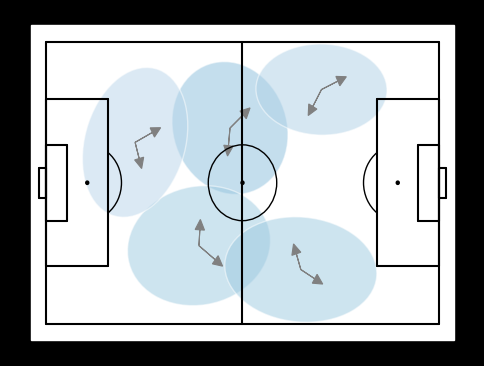

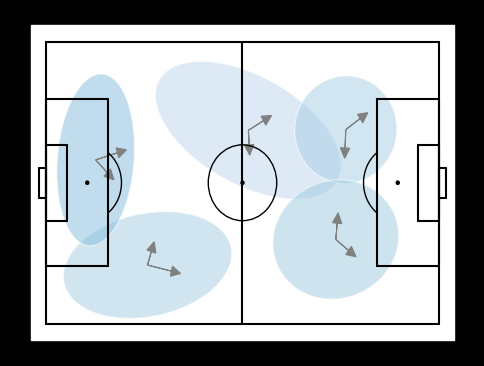

In [12]:
action_name = "pass"
model.emission.action_mom_[0][action_name].plot()
model.emission.action_mom_[1][action_name].plot()

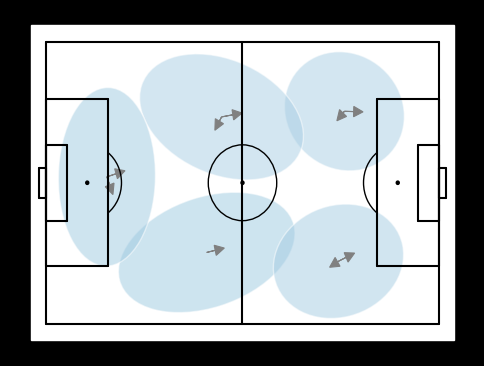

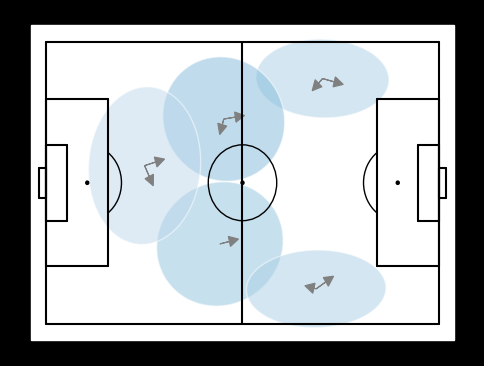

In [14]:
action_name = "dribble"
model.emission.action_mom_[0][action_name].plot()
model.emission.action_mom_[1][action_name].plot()